# MNIST End-to-End — TensorFlow / Keras

> **Self-contained E2E notebook.** Run top-to-bottom in a fresh kernel. It covers data loading, quality checks, deterministic train/validation/test separation, preprocessing, batching, ANN definition, training, validation, final test evaluation, error analysis, serialization/reload, and inference.

**Lifecycle:** raw MNIST → validate data → split → preprocess → batch → ANN → loss/backprop → validation → final test → metrics → save/reload → inference.

**Architecture:** `784 → 128 → ReLU → 64 → ReLU → 10 logits`.


## 1. Imports, reproducibility, and paths

Seeds make the experiment repeatable. Data and model artifacts are stored under `data/` and `artifacts/`.


In [1]:
from pathlib import Path
import random, urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR, ARTIFACT_DIR = ROOT / "data", ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True); ARTIFACT_DIR.mkdir(exist_ok=True)
print("TensorFlow",tf.__version__)


2026-09-07 19:34:43.508597: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0


## 2. Load the official MNIST archive and validate it

Both framework notebooks use the exact same `mnist.npz` source. We validate shape, label domain, missingness, and pixel range before modeling. These checks mirror production data contracts.


In [2]:
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
MNIST_PATH = DATA_DIR / "mnist.npz"
if not MNIST_PATH.exists():
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_full, y_full = data["x_train"], data["y_train"]
    x_test_raw, y_test = data["x_test"], data["y_test"]
assert x_full.shape == (60000, 28, 28) and x_test_raw.shape == (10000, 28, 28)
assert set(np.unique(y_full)) == set(range(10))
assert not np.isnan(x_full.astype("float32")).any()
assert x_full.min() >= 0 and x_full.max() <= 255
print("development:", x_full.shape, y_full.shape)
print("test:", x_test_raw.shape, y_test.shape)
display(pd.Series(y_full).value_counts().sort_index().rename("count").to_frame())


development: (60000, 28, 28) (60000,)
test: (10000, 28, 28) (10000,)


,count
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851
9,5949


## 3. Deterministic train / validation / test separation

The official 10,000-image test set remains untouched until final evaluation. We stratify only the original training set into **50,000 train** and **10,000 validation** examples. Train learns parameters; validation guides development; test is the final acceptance set.


In [3]:
x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    x_full, y_full, test_size=10000, random_state=SEED, stratify=y_full
)
print("train:", x_train_raw.shape, y_train.shape)
print("validation:", x_val_raw.shape, y_val.shape)
print("test:", x_test_raw.shape, y_test.shape)

def preprocess(x):
    return x.reshape(len(x), 784).astype("float32") / 255.0

x_train, x_val, x_test = map(preprocess, [x_train_raw, x_val_raw, x_test_raw])
print("normalized range:", float(x_train.min()), float(x_train.max()))


train: (50000, 28, 28) (50000,)
validation: (10000, 28, 28) (10000,)
test: (10000, 28, 28) (10000,)
normalized range: 0.0 1.0


## 4. Build the TensorFlow input pipeline and ANN

The input to the network has shape `[batch, 784]`. The final layer emits **logits**, not probabilities. ReLU provides non-linearity and He/Kaiming-style initialization supports stable ReLU signal propagation.


In [4]:
BATCH_SIZE=256
train_ds=tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(len(x_train),seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds=tf.data.Dataset.from_tensor_slices((x_val,y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds=tf.data.Dataset.from_tensor_slices((x_test,y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
@tf.keras.utils.register_keras_serializable(package="ann_e2e")
class MNISTMLP(tf.keras.Model):
    def __init__(self,**kwargs):
        super().__init__(**kwargs); self.fc1=tf.keras.layers.Dense(128,activation="relu",kernel_initializer="he_normal"); self.fc2=tf.keras.layers.Dense(64,activation="relu",kernel_initializer="he_normal"); self.out=tf.keras.layers.Dense(10)
    def call(self,x,training=False): return self.out(self.fc2(self.fc1(x)))
model=MNISTMLP(name="mnist_mlp"); _=model(tf.zeros((1,784))); model.summary()
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True); optimizer=tf.keras.optimizers.Adam(1e-3)


Model: "mnist_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 128)               │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 64)                │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 10)                │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train and validate every epoch

Training performs gradient-based parameter updates. Validation runs after each epoch **without updating parameters**, giving generalization feedback while protecting the final test set.


In [5]:
def train_one_epoch(ds):
    lm=tf.keras.metrics.Mean(); am=tf.keras.metrics.SparseCategoricalAccuracy()
    for features, labels in ds:
        with tf.GradientTape() as tape:
            logits=model(features,training=True); loss=loss_fn(labels,logits)
        grads=tape.gradient(loss,model.trainable_variables); optimizer.apply_gradients(zip(grads,model.trainable_variables)); lm.update_state(loss); am.update_state(labels,logits)
    return float(lm.result()),float(am.result())
def evaluate(ds):
    lm=tf.keras.metrics.Mean(); am=tf.keras.metrics.SparseCategoricalAccuracy()
    for features, labels in ds:
        logits=model(features,training=False); loss=loss_fn(labels,logits); lm.update_state(loss); am.update_state(labels,logits)
    return float(lm.result()),float(am.result())
history=[]
for epoch in range(1,6):
    tl,ta=train_one_epoch(train_ds); vl,va=evaluate(val_ds)
    history.append(dict(epoch=epoch,train_loss=tl,train_accuracy=ta,val_loss=vl,val_accuracy=va))
    print(f"epoch={epoch} train_loss={tl:.4f} train_acc={ta:.4f} val_loss={vl:.4f} val_acc={va:.4f}")


2026-09-07 19:34:50.341020: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-09-07 19:34:50.578600: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch=1 train_loss=0.4379 train_acc=0.8791 val_loss=0.2145 val_acc=0.9367


2026-09-07 19:34:55.002929: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch=2 train_loss=0.1746 train_acc=0.9494 val_loss=0.1689 val_acc=0.9496


epoch=3 train_loss=0.1279 train_acc=0.9636 val_loss=0.1304 val_acc=0.9608


2026-09-07 19:35:03.927760: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


epoch=4 train_loss=0.1001 train_acc=0.9703 val_loss=0.1186 val_acc=0.9627


epoch=5 train_loss=0.0800 train_acc=0.9765 val_loss=0.1039 val_acc=0.9687


## 6. Learning curves and final untouched test evaluation

Training/validation curves expose convergence and overfitting. Only after development is complete do we evaluate the official test set. Accuracy is complemented with per-class precision/recall/F1 and a confusion matrix.


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,0.437885,0.87908,0.214467,0.9367
1,2,0.174562,0.94938,0.168924,0.9496
2,3,0.127906,0.96356,0.130434,0.9608
3,4,0.100100,0.97032,0.118561,0.9627
4,5,0.080037,0.97646,0.103905,0.9687


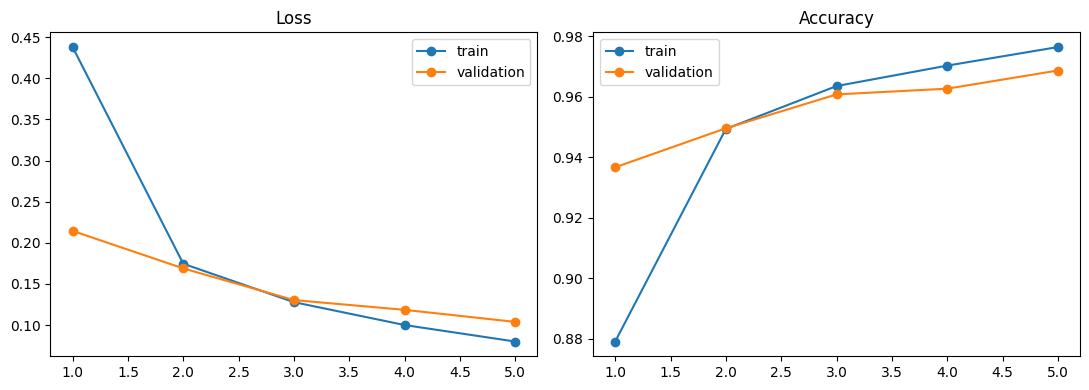

test_loss=0.0932 test_accuracy=0.9715
              precision    recall  f1-score   support

           0     0.9758    0.9857    0.9807       980
           1     0.9868    0.9850    0.9859      1135
           2     0.9754    0.9603    0.9678      1032
           3     0.9449    0.9842    0.9641      1010
           4     0.9640    0.9807    0.9722       982
           5     0.9687    0.9709    0.9698       892
           6     0.9810    0.9697    0.9753       958
           7     0.9764    0.9650    0.9706      1028
           8     0.9698    0.9548    0.9622       974
           9     0.9718    0.9574    0.9646      1009

    accuracy                         0.9715     10000
   macro avg     0.9714    0.9714    0.9713     10000
weighted avg     0.9716    0.9715    0.9715     10000



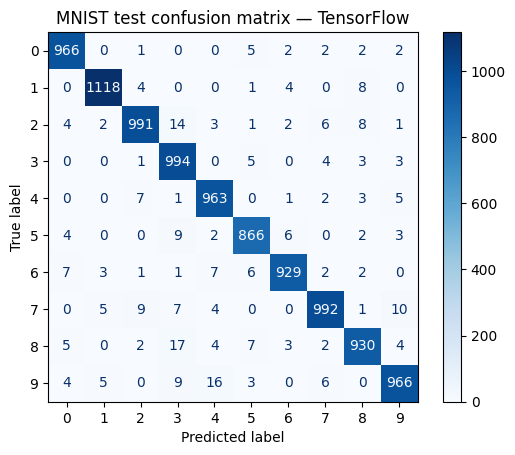

In [6]:
history_df = pd.DataFrame(history)
display(history_df)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_df.epoch, history_df.train_loss, marker="o", label="train")
axes[0].plot(history_df.epoch, history_df.val_loss, marker="o", label="validation")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history_df.epoch, history_df.train_accuracy, marker="o", label="train")
axes[1].plot(history_df.epoch, history_df.val_accuracy, marker="o", label="validation")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

test_loss,test_accuracy=evaluate(test_ds)
print(f"test_loss={test_loss:.4f} test_accuracy={test_accuracy:.4f}")
logits=model.predict(x_test,batch_size=BATCH_SIZE,verbose=0); probs=tf.nn.softmax(logits,axis=1).numpy(); predictions=probs.argmax(1); targets=y_test
print(classification_report(targets,predictions,digits=4))
cm=confusion_matrix(targets,predictions); ConfusionMatrixDisplay(cm).plot(cmap="Blues",values_format="d"); plt.title("MNIST test confusion matrix — TensorFlow"); plt.show()


## 7. Error analysis

Aggregate metrics do not explain individual failures. We inspect high-confidence mistakes because confidently wrong predictions are especially risky in automated production decisions.


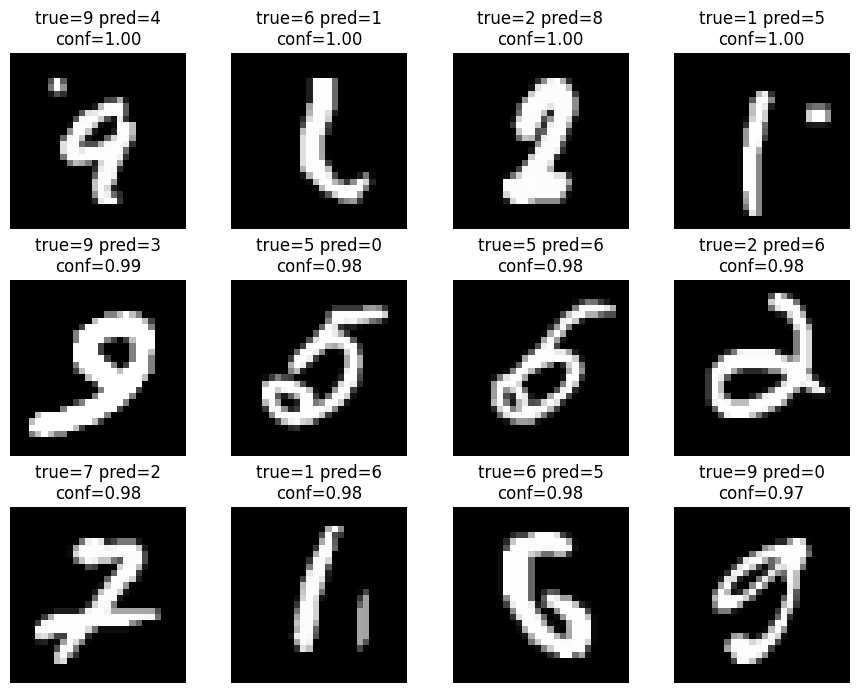

In [7]:
confidence = probs.max(axis=1)
wrong = np.flatnonzero(predictions != targets)
hardest = wrong[np.argsort(confidence[wrong])[-12:]][::-1]
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for idx, ax in zip(hardest, axes.ravel()):
    ax.imshow(x_test_raw[idx], cmap="gray")
    ax.set_title(f"true={targets[idx]} pred={predictions[idx]}\nconf={confidence[idx]:.2f}")
    ax.axis("off")
plt.tight_layout(); plt.show()


## 8. Save, reload, and verify parity

A production artifact must survive process boundaries. We save the trained model, reload it into a fresh object, and verify that predictions are unchanged.


In [8]:
MODEL_PATH=ARTIFACT_DIR/"mnist_tensorflow_mlp.keras"
model.save(MODEL_PATH)
reloaded_model=tf.keras.models.load_model(MODEL_PATH,custom_objects={"MNISTMLP":MNISTMLP})
a=tf.argmax(model(x_test[:32],training=False),axis=1); b=tf.argmax(reloaded_model(x_test[:32],training=False),axis=1); tf.debugging.assert_equal(a,b)
print("reload parity verified:",MODEL_PATH)


reload parity verified: /home/runner/work/awesome-deep-learning-resource/awesome-deep-learning-resource/artifacts/mnist_tensorflow_mlp.keras


## 9. Single-sample inference contract

Inference repeats exactly the training preprocessing and returns the predicted class, confidence, and complete probability vector. This is the boundary an API or batch-scoring service would expose.


In [9]:
def predict_one(raw_image, trained_model):
    features=raw_image.reshape(1,784).astype("float32")/255.0
    p=tf.nn.softmax(trained_model(features,training=False),axis=1).numpy()[0]; cls=int(p.argmax())
    return {"predicted_class":cls,"confidence":float(p[cls]),"probabilities":p}
result=predict_one(x_test_raw[0],reloaded_model)
print("true",int(y_test[0]),"predicted",result["predicted_class"],"confidence",round(result["confidence"],4))


true 7 predicted 7 confidence 0.9986


## Completion checklist

- official MNIST provenance and data-quality assertions ✅
- isolated train / validation / test lifecycle ✅
- preprocessing and batching ✅
- ANN architecture and initialization ✅
- explicit optimization/training loop ✅
- epoch-level validation ✅
- final untouched test evaluation ✅
- precision / recall / F1 / confusion matrix ✅
- error analysis ✅
- serialization / reload parity ✅
- production-style single inference function ✅

This is the compact **end-to-end reference implementation**. The larger Manual/PyTorch/TensorFlow branches remain the deep conceptual courses.
